In [29]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [30]:
def f(x):
    return x**2+2*x**3

In [31]:
f(3)

63

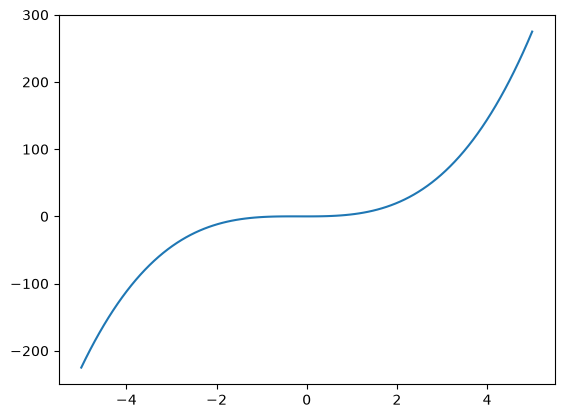

In [32]:
y_s = f(np.linspace(-5, 5, 100))
plt.plot(np.linspace(-5, 5, 100), y_s)

In [33]:
print(f(3),f(4))

63 144


In [34]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
        
    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    def __neg__(self): # -self
        return self * -1
    def __sub__(self, other): # self - other
        return self + (-other)

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [35]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [36]:
a = Value(3.0, label='a')
b = Value(2.0, label='b')
c = a + b; c.label = 'c'
d = a * b; d.label = 'd'
final = c + d; final.label = 'final'

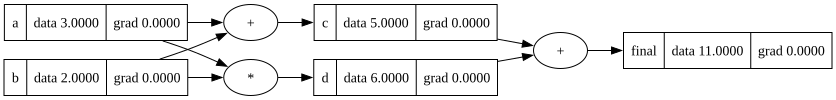

In [37]:
draw_dot(final)

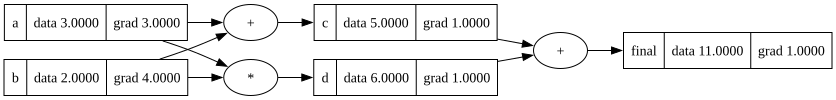

In [38]:
final.backward()
draw_dot(final)

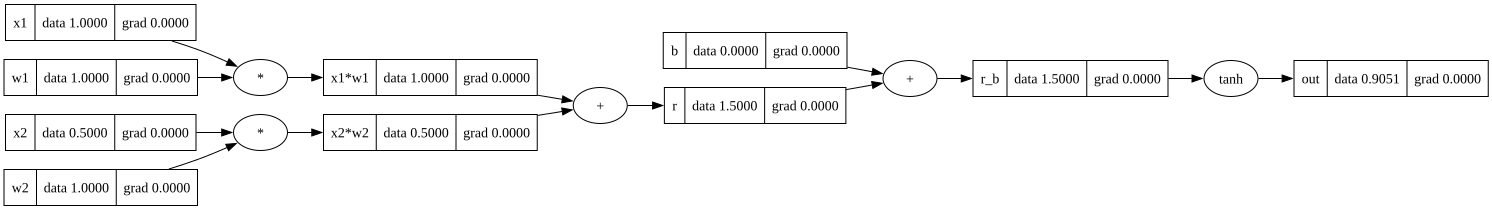

In [39]:
# mimic neural network forward pass
# inputs
x1 = Value(1.0, label='x1')
x2 = Value(0.5, label='x2')
# synapses
w1 = Value(1.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(0.0, label='b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
r = x1w1 + x2w2; r.label = 'r'
r_b = r + b; r_b.label = 'r_b'
out = r_b.tanh(); out.label = 'out'
# prob = (out + 1) * 0.5; prob.label = 'P' # P = (tanh(R+b) + 1) / 2

draw_dot(out)

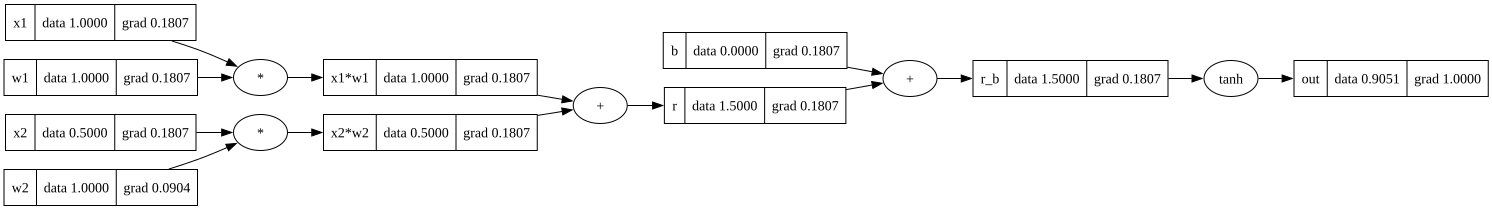

In [40]:
out.backward()
draw_dot(out)

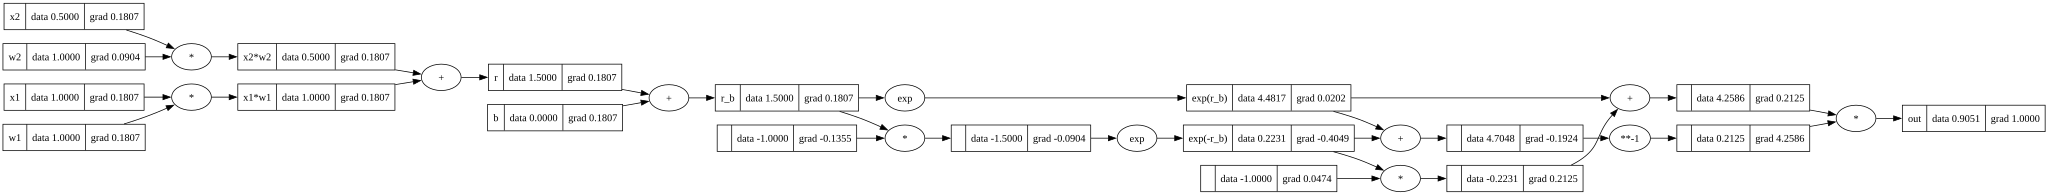

In [42]:
# mimic neural network forward pass
# inputs
x1 = Value(1.0, label='x1')
x2 = Value(0.5, label='x2')
# synapses
w1 = Value(1.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(0.0, label='b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
r = x1w1 + x2w2; r.label = 'r'
r_b = r + b; r_b.label = 'r_b'
## building tanh using exp
exp_r_b = r_b.exp(); exp_r_b.label = 'exp(r_b)'
exp_neg_r_b = (-r_b).exp(); exp_neg_r_b.label = 'exp(-r_b)'
out = (exp_r_b - exp_neg_r_b) / (exp_r_b + exp_neg_r_b); out.label = 'out'

out.backward()
draw_dot(out)

In [1]:
import torch

In [3]:
# doing same thing using pytorch
x1 = torch.tensor(1.0, requires_grad=True)
x2 = torch.tensor(0.5, requires_grad=True)
w1 = torch.tensor(1.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
net = x1 * w1 + x2 * w2 + b
out = torch.tanh(net)

print(out)
out.backward()
print(x1.grad, x2.grad, w1.grad, w2.grad, b.grad)

tensor(0.9051, grad_fn=<TanhBackward0>)
tensor(0.1807) tensor(0.1807) tensor(0.1807) tensor(0.0904) tensor(0.1807)


In [5]:
#neuron class
class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.randn()) for _ in range(nin)]
        self.b = Value(0.0)
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):

        return self.w + [self.b]

#layer class
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

# MLP class
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
